#**Summary**

#**Summary**

This notebook builds and evaluates three sparse index-tracking methods on the S&P 500, using the model-ready weekly returns produced in Notebook 01. The pipeline establishes a unified walk-forward backtest framework, implements each method behind a common interface, runs the in-sample backtest, and characterizes the results through a performance table and four visualizations. Every methodological choice is documented inline, and all results are persisted for the out-of-sample evaluation in Notebook 03.

**Backtest framework.** I use a walk-forward design with a 52-week rolling lookback and rebalancing every 4 weeks. At each rebalance the model is refitted on the most recent 52 weeks, so the portfolio adapts continuously to market conditions rather than being fit once. The in-sample period spans 2016-01-15 to 2023-01-13 (79 monthly rebalances). A point-in-time universe filter admits only assets that were index constituents with full lookback history at each date, avoiding lookahead and survivorship bias. The 70/30 in-sample/out-of-sample split separates the period used for methodology calibration from the period reserved for unbiased final evaluation; it is not a single train/test fit.

**Three methods.** All three are exposed through a common `fit_function(X, r_b, K, date, tickers)` interface and share the same backtest engine. Market-cap top-K is a non-optimization baseline that selects the K largest constituents and weights them by capitalization. LASSO with cardinality control uses L1-regularized least squares to select assets, followed by a budget-constrained refit on the selected support; bisection over the penalty parameter targets the desired K. Benidis SLAIT solves the L0-constrained tracking problem directly via the authors' R package `sparseIndexTracking`, called through rpy2, with the same bisection strategy over its sparsity parameter.

**SLAIT reproducibility and tuning.** The R solver defaults to random initialization, which made it non-reproducible and destabilized the bisection. Passing an explicit equal-weight start (`w0 = 1/N`) fixed both issues. Combined with a tightened iteration cap and early termination on the first exact cardinality match, this cut the per-solve time from roughly 22 seconds to about 10 seconds.

**In-sample results.** Tracking error declines monotonically with cardinality for all methods. SLAIT is the strongest tracker wherever evaluated, achieving 6.25% tracking error at K=10 — better than top-K at K=30 — and 4.20% at K=50. LASSO is weakest at low cardinality (20.47% at K=10, with near-zero cumulative return) but matches top-K by K=50, confirming that L1 selection requires sufficient cardinality to function. Top-K is a stable, low-turnover baseline that declines smoothly to 3.44% at K=100. LASSO at K=100 is infeasible: under non-negativity it cannot select 100 assets even at minimal regularization, which is documented as a structural property rather than a bug.

**Realised cardinality and turnover.** LASSO consistently holds fewer assets than its target K (a median of 8 at K=10, 33 at K=50), because the non-negative refit zeros out redundant selected assets; the analysis therefore reports both target K and mean realised K_eff. The composition heatmaps reveal a stability-versus-accuracy trade-off: top-K holds an almost-fixed mega-cap core (19 unique tickers over the period, AAPL in all 79 rebalances), while SLAIT cycles through 257 unique tickers yet tracks most tightly — high turnover is the mechanism behind its accuracy, not a defect.

**Persisted artifacts.** The in-sample backtest returns, transaction costs, rebalance weights, and performance metrics are saved to Google Drive in Parquet format, alongside the share-count cache reused by top-K. A JSON manifest records the configuration (lookback, rebalance frequency, cardinality grids, transaction cost, period boundaries) and the contents of each artifact, so that Notebook 03 can verify consistency before running the out-of-sample evaluation.

#Imports and Setup

This block installs and imports all libraries used in the notebook.

**Library groups:**
- Data manipulation: `pandas`, `numpy`, `requests`, etc
- Market data: `yfinance`, etc
- Optimization: `cvxpy`, `scipy.optimize`, etc
- R integration: `rpy2` (interface to the R `sparseIndexTracking` package for the SLAIT method)
- Visualization: `matplotlib`, etc
- Utilities: `tqdm`, `warnings`, `os`, `time`, etc

The `rpy2` library and the underlying R `sparseIndexTracking` package are required for the SLAIT method. The package is provided by the authors of Benidis, Feng, and Palomar (2018) and is the canonical implementation of the SLAIT/LAIT algorithms.

In [46]:
!pip install yfinance --quiet
!pip install cvxpy --quiet


import os
import re
import time
import warnings
from io import StringIO
import json

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import cvxpy as cp
from scipy.optimize import brentq

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm


# rpy2 setup
import rpy2.robjects as ro
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import numpy2ri, pandas2ri

numpy2ri.activate()
pandas2ri.activate()

# Suppress R console output
rpy2.rinterface_lib.callbacks.consolewrite_print = lambda x: None
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = lambda x: None

# Install the R package sparseIndexTracking if not already present
ro.r('''
suppressPackageStartupMessages(suppressMessages(suppressWarnings({
    if (!require("sparseIndexTracking", quietly = TRUE)) {
        install.packages("sparseIndexTracking", repos = "http://cran.r-project.org", quiet = TRUE)
    }
    library(sparseIndexTracking)
})))
''')


# Drive mount and paths
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_DIR = '/content/drive/MyDrive/ml_finance_project_index_tracking'
CACHE_DIR = f'{PROJECT_DIR}/cache_modeling'
os.makedirs(CACHE_DIR, exist_ok=True)


# Reproducibility
SEED = 100
np.random.seed(SEED)


# Display settings
from google.colab import data_table
data_table.disable_dataframe_formatter()

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

warnings.filterwarnings('ignore')


# Version info
print(f"numpy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"yfinance:    {yf.__version__}")
print(f"cvxpy:       {cp.__version__}")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"CACHE_DIR:   {CACHE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
numpy:       2.0.2
pandas:      2.2.2
yfinance:    0.2.66
cvxpy:       1.6.7
PROJECT_DIR: /content/drive/MyDrive/ml_finance_project_index_tracking
CACHE_DIR:   /content/drive/MyDrive/ml_finance_project_index_tracking/cache_modeling


#Data Loading

**Artifacts from Notebook with Data Collection**

This section loads the artifacts produced by the data collection notebook (`01_data_collection.ipynb`). The modeling notebook does not re-run any data acquisition step — all data preparation is encapsulated in the first notebook, and the outputs flow through Google Drive in Parquet format.

The artifacts consumed by this notebook:

- `returns_weekly.parquet` — weekly simple returns of 611 tickers (the ML-ready dataset). Shape (523, 611), date range 2016-01-15 to 2026-01-16.
- `index_returns_weekly.parquet` — weekly simple returns of the `^SP500TR` benchmark, aligned with `returns_weekly`.
- `constituents.parquet` — point-in-time composition of the S&P 500. For each historical date, lists the tickers that were members of the index on that date. Used for point-in-time universe filtering during the backtest.
- `prices_daily_raw.parquet` — daily prices for all 612 downloaded tickers. Needed for computing time-varying market capitalization.
- `ticker_availability.parquet` — per-ticker first/last dates and coverage metrics. Used for diagnostics.
- `universe_filtered.txt` — final list of 611 original ticker symbols (after exclusion of `CCE`).

In [17]:
# Load all artifacts produced by 01_data_collection.ipynb
returns_weekly = pd.read_parquet(f'{PROJECT_DIR}/returns_weekly.parquet')
index_returns_weekly = pd.read_parquet(f'{PROJECT_DIR}/index_returns_weekly.parquet')['return']
constituents = pd.read_parquet(f'{PROJECT_DIR}/constituents.parquet')
prices_daily = pd.read_parquet(f'{PROJECT_DIR}/prices_daily_raw.parquet')
ticker_availability = pd.read_parquet(f'{PROJECT_DIR}/ticker_availability.parquet')

with open(f'{PROJECT_DIR}/universe_filtered.txt') as f:
    universe_filtered = [line.strip() for line in f.readlines()]


# Alignment check between assets and the benchmark index
assert (returns_weekly.index == index_returns_weekly.index).all(), \
    "Assets and index returns have different date indices"


# Summary
print(f"Loaded artifacts:")
print(f"  returns_weekly:        {returns_weekly.shape}")
print(f"  index_returns_weekly:  {index_returns_weekly.shape}")
print(f"  constituents:          {constituents.shape}")
print(f"  prices_daily:          {prices_daily.shape}")
print(f"  ticker_availability:   {ticker_availability.shape}")
print(f"  universe_filtered:     {len(universe_filtered)} tickers")

print(f"\nWeekly returns date range:")
print(f"  {returns_weekly.index.min().date()} to {returns_weekly.index.max().date()}")
print(f"  Total weekly observations: {len(returns_weekly)}")

print(f"\nAlignment check: passed.")

Loaded artifacts:
  returns_weekly:        (523, 611)
  index_returns_weekly:  (523,)
  constituents:          (475, 2)
  prices_daily:          (2523, 612)
  ticker_availability:   (729, 8)
  universe_filtered:     611 tickers

Weekly returns date range:
  2016-01-15 to 2026-01-16
  Total weekly observations: 523

Alignment check: passed.


**Auxiliary Data: Shares Outstanding**

The market-capitalization top-K method requires the market cap of each candidate asset at each historical rebalancing date. Since `yfinance` provides only the current snapshot of `marketCap`, I instead retrieve `sharesOutstanding` — a more stable quantity that changes only with buybacks and issuances — and combine it with historical prices at each rebalancing date to approximate point-in-time market cap.

The approximation introduces a small bias for tickers with significant share count changes during the period (large buybacks or secondary issuances), but the direction of this bias is not systematic across methods, so it does not affect relative comparisons between top-K, LASSO, and SLAIT.

**Processing pipeline:**

- **Step 1. Check cache.** Results are persisted to Google Drive after the first run. Subsequent notebook runs load from cache instantly.
- **Step 2. Fetch via yfinance.** If the cache is empty, query `yf.Ticker(t).info['sharesOutstanding']` for each ticker in the universe. Rate-limit at 0.3 seconds between requests to avoid Yahoo Finance throttling.
- **Step 3. Filter and persist.** Discard tickers for which `sharesOutstanding` is missing (typically delisted or renamed companies that yfinance no longer maintains). Save the result as a Parquet file in `CACHE_DIR`.

In [18]:
SHARES_CACHE_FILE = f'{CACHE_DIR}/shares_outstanding.parquet'


def to_yahoo_ticker(t):
    """Convert original ticker to Yahoo Finance format (e.g., BRK.B -> BRK-B)."""
    return t.replace('.', '-')


# Step 1. Check cache
if os.path.exists(SHARES_CACHE_FILE):
    shares_df = pd.read_parquet(SHARES_CACHE_FILE)
    print(f"Loaded from cache: {len(shares_df)} tickers with sharesOutstanding.")
else:
# Step 2. Fetch via yfinance
    print(f"Cache miss. Fetching sharesOutstanding via yfinance (~5 min)...")
    records = []
    missing = []

    for original_ticker in tqdm(universe_filtered, desc='Fetching shares'):
        yahoo_ticker = to_yahoo_ticker(original_ticker)
        try:
            info = yf.Ticker(yahoo_ticker).info
            shares = info.get('sharesOutstanding', None)
            if shares is not None and shares > 0:
                records.append({
                    'ticker': original_ticker,
                    'yahoo_ticker': yahoo_ticker,
                    'shares_outstanding': float(shares),
                })
            else:
                missing.append(original_ticker)
        except Exception:
            missing.append(original_ticker)
        time.sleep(0.3)

# Step 3. Build DataFrame and cache
    shares_df = pd.DataFrame(records).set_index('ticker')
    shares_df.to_parquet(SHARES_CACHE_FILE)

    print(f"\nRetrieved sharesOutstanding for {len(shares_df)} of {len(universe_filtered)} tickers.")
    if missing:
        print(f"Missing ({len(missing)}): {missing[:10]}{'...' if len(missing) > 10 else ''}")
    print(f"Cached to {SHARES_CACHE_FILE}")

print(f"\nshares_df.head():")
print(shares_df.head())

# Compute market cap proxy for all tickers, show top 5
last_prices = prices_daily.iloc[-1]
proxy_market_caps = []
for ticker in shares_df.index:
    yahoo_t = shares_df.loc[ticker, 'yahoo_ticker']
    if yahoo_t in last_prices.index and pd.notna(last_prices[yahoo_t]):
        mc = last_prices[yahoo_t] * shares_df.loc[ticker, 'shares_outstanding']
        proxy_market_caps.append({'ticker': ticker, 'market_cap': mc})

mc_df = pd.DataFrame(proxy_market_caps).sort_values('market_cap', ascending=False).reset_index(drop=True)

print(f"\nTop 5 by market cap proxy (last close x current shares):")
for _, row in mc_df.head(5).iterrows():
    print(f"  {row['ticker']:<6}: ${row['market_cap'] / 1e12:.2f}T")

Loaded from cache: 594 tickers with sharesOutstanding.

shares_df.head():
       yahoo_ticker  shares_outstanding
ticker                                 
A                 A        2.826023e+08
AAL             AAL        6.613851e+08
AAP             AAP        6.032921e+07
AAPL           AAPL        1.468736e+10
ABBV           ABBV        1.766793e+09

Top 5 by market cap proxy (last close x current shares):
  NVDA  : $4.44T
  AAPL  : $3.81T
  MSFT  : $3.40T
  AMZN  : $2.55T
  GOOGL : $1.95T


#Backtest Framework

**Walk-Forward Methodology**

The backtest uses a walk-forward (rolling-window) design that all three methods share. At each rebalancing date `t`, the model is re-fitted on the prior window `[t - L, t]`, and the resulting weights are held over `[t, t + H]`. This mimics the operating constraints of a real portfolio manager: only past data is observable at each decision point.

**Lookback `L = 52` weeks.** One year of weekly returns per fit. The choice balances three competing requirements: sufficient sample size for the high-dimensional regression (`p ≫ N` regime with ~500 assets), recency relative to the time-varying S&P 500 composition, and computational tractability across many rebalancing dates.

**Rebalancing `H = 4` weeks.** Monthly rebalancing as the primary configuration; weekly and quarterly are reported as robustness checks.

**In-sample / out-of-sample split (70 / 30).** The first 70% of observations is used for hyperparameter selection. The remaining 30% is reserved for the final evaluation in Notebook 03_Evaluation.

**Point-in-time universe filtering.** At each rebalancing date `t`, candidate assets must (a) have been S&P 500 constituents on that date and (b) have a complete return history over `[t - L, t]`. This protects against look-ahead bias from IPOs, spin-offs, and delistings.

**Transaction costs.** A standard `TC = 10 bps` per side is applied to the absolute weight change at each rebalance. A sensitivity analysis reports `TC ∈ {0, 5, 10, 20}` bps.

The full design follows [Benidis, Feng, and Palomar (2018)](https://palomar.home.ece.ust.hk/papers/2018/BenidisFengPalomar-TSP2018%20-%20index_tracking.pdf).

**Configuration**

All backtest parameters are collected here in one place. This makes the setup explicit and easy to modify for sensitivity analyses or future replication of the results.

In [30]:
# Walk-forward parameters
LOOKBACK_WEEKS       = 52
REBALANCE_FREQ_WEEKS = 4
IS_FRACTION          = 0.70

# Method hyperparameters
K_VALUES_FAST  = [10, 30, 50, 100]  # for top-K and LASSO (cheap methods)
K_VALUES_SLAIT = [10, 50]            # for SLAIT (expensive, R-based)
TC_BPS_VALUES = [0, 5, 10, 20]
MAIN_TC_BPS   = 10

# Derived constants
TOTAL_WEEKS = len(returns_weekly)
N_IS_WEEKS  = int(TOTAL_WEEKS * IS_FRACTION)
N_OOS_WEEKS = TOTAL_WEEKS - N_IS_WEEKS

IS_START_DATE  = returns_weekly.index[0]
IS_END_DATE    = returns_weekly.index[N_IS_WEEKS - 1]
OOS_START_DATE = returns_weekly.index[N_IS_WEEKS]
OOS_END_DATE   = returns_weekly.index[-1]

# Rebalancing dates: every REBALANCE_FREQ_WEEKS, starting after the first lookback window
first_rebalance_idx = LOOKBACK_WEEKS
rebalance_indices = list(range(first_rebalance_idx, TOTAL_WEEKS, REBALANCE_FREQ_WEEKS))
rebalance_dates = returns_weekly.index[rebalance_indices]

rebalance_dates_is  = [d for d in rebalance_dates if d <= IS_END_DATE]
rebalance_dates_oos = [d for d in rebalance_dates if d > IS_END_DATE]


# Summary
print(f"Walk-forward parameters:")
print(f"  Lookback window:           {LOOKBACK_WEEKS} weeks")
print(f"  Rebalancing frequency:     {REBALANCE_FREQ_WEEKS} weeks")
print(f"  In-sample fraction:        {IS_FRACTION:.0%}")

print(f"\nSample split:")
print(f"  Total weekly observations: {TOTAL_WEEKS}")
print(f"  In-sample observations:    {N_IS_WEEKS} ({IS_START_DATE.date()} to {IS_END_DATE.date()})")
print(f"  Out-of-sample observations: {N_OOS_WEEKS} ({OOS_START_DATE.date()} to {OOS_END_DATE.date()})")

print(f"\nRebalancing dates:")
print(f"  Total rebalances:          {len(rebalance_dates)}")
print(f"  In-sample rebalances:      {len(rebalance_dates_is)}")
print(f"  Out-of-sample rebalances:  {len(rebalance_dates_oos)}")

print(f"\nMethod hyperparameters:")
print(f"  K values (fast methods):   {K_VALUES_FAST}")
print(f"  K values (SLAIT):          {K_VALUES_SLAIT}")
print(f"  Transaction costs:         {TC_BPS_VALUES} bps")
print(f"  Main TC for headline:      {MAIN_TC_BPS} bps")

Walk-forward parameters:
  Lookback window:           52 weeks
  Rebalancing frequency:     4 weeks
  In-sample fraction:        70%

Sample split:
  Total weekly observations: 523
  In-sample observations:    366 (2016-01-15 to 2023-01-13)
  Out-of-sample observations: 157 (2023-01-20 to 2026-01-16)

Rebalancing dates:
  Total rebalances:          118
  In-sample rebalances:      79
  Out-of-sample rebalances:  39

Method hyperparameters:
  K values (fast methods):   [10, 30, 50, 100]
  K values (SLAIT):          [10, 50]
  Transaction costs:         [0, 5, 10, 20] bps
  Main TC for headline:      10 bps


**Point-in-Time Universe Filter**

The function `get_pit_universe(date)` returns the set of tickers eligible for inclusion in the tracking portfolio on a given rebalancing date. Three filters are applied in sequence:

1. **Membership filter.** The ticker must have been a S&P 500 constituent on `date`, according to the most recent composition record on or before `date` in `constituents`.

2. **History filter.** The ticker must have non-missing weekly returns over the full lookback window `[date - LOOKBACK_WEEKS, date]`. This excludes assets with insufficient history at the rebalancing date (e.g., a company that IPO'd two months ago).

3. **Optional shares filter.** For methods that require time-varying market capitalization, the ticker must additionally have `sharesOutstanding` available in `shares_df`.

In [20]:
# Pre-compute the constituents lookup for efficient point-in-time queries
constituents_sorted = constituents.sort_values('date').reset_index(drop=True)


def constituents_on_date(d):
    """Return the list of original tickers in the S&P 500 on or before date d.

    Uses the most recent composition recorded on or before d in `constituents`.
    Returns an empty list if no composition is available for d.
    """
    idx = constituents_sorted['date'].searchsorted(d, side='right') - 1
    if idx < 0:
        return []
    tickers_str = constituents_sorted.iloc[idx]['tickers']
    return [t.strip() for t in tickers_str.split(',')]


def get_pit_universe(date, lookback_weeks=LOOKBACK_WEEKS, require_shares=False):
    """Return the point-in-time eligible universe of tickers as of `date`.

    Parameters
    ----------
    date : pd.Timestamp
        Rebalancing date. Must be present in `returns_weekly.index`.
    lookback_weeks : int
        Required length of complete return history.
    require_shares : bool
        If True, additionally require the ticker to be in `shares_df`.

    Returns
    -------
    list of str
        Original (non-Yahoo-formatted) ticker symbols.
    """
    # Filter 1: S&P 500 constituents on this date
    constituent_tickers = set(constituents_on_date(date))

    # Filter 2: tickers with full lookback history in returns_weekly
    date_idx = returns_weekly.index.get_loc(date)
    if date_idx < lookback_weeks:
        return []

    lookback_slice = returns_weekly.iloc[date_idx - lookback_weeks:date_idx]

    valid_tickers = []
    for orig in constituent_tickers:
        yahoo = to_yahoo_ticker(orig)
        if yahoo in lookback_slice.columns:
            if lookback_slice[yahoo].notna().all():
                valid_tickers.append(orig)

    # Filter 3 (optional): tickers with sharesOutstanding available
    if require_shares:
        valid_tickers = [t for t in valid_tickers if t in shares_df.index]

    return valid_tickers


# Sanity check on three representative rebalancing dates
print(f"PIT universe sanity check across the period:")
print(f"{'Date':>12s}  {'Constituents':>14s}  {'With full history':>18s}  {'With shares':>13s}")

sample_dates = [
    rebalance_dates[0],                          # earliest rebalance
    rebalance_dates[len(rebalance_dates) // 2],  # middle
    rebalance_dates[-1],                         # latest
]

for d in sample_dates:
    n_cons = len(constituents_on_date(d))
    n_hist = len(get_pit_universe(d, require_shares=False))
    n_shares = len(get_pit_universe(d, require_shares=True))
    print(f"  {str(d.date()):>10s}  {n_cons:>14d}  {n_hist:>18d}  {n_shares:>13d}")

PIT universe sanity check across the period:
        Date    Constituents   With full history    With shares
  2017-01-13             506                 412            402
  2021-07-23             505                 458            458
  2026-01-02             503                 499            499


**Performance Metrics**

The function `compute_performance_metrics(portfolio_returns, index_returns, weights_history)` computes the standard set of metrics used to evaluate a tracking portfolio. The same function is applied to all methods, both in-sample and out-of-sample, ensuring fair comparison.

**Metrics:**

- `tracking_error_ann` — annualized standard deviation of the return difference between portfolio and index: `std(r_p - r_b) × sqrt(52)`.
- `ann_return` — compound annual growth rate (CAGR) of the portfolio.
- `ann_volatility` — annualized standard deviation of portfolio returns: `std(r_p) × sqrt(52)`.
- `sharpe` — ratio of `ann_return` to `ann_volatility`. The risk-free rate is taken as zero, which is standard practice in index-tracking studies.
- `max_drawdown` — largest peak-to-trough decline of cumulative portfolio returns.
- `turnover_ann` — annualized one-way turnover, computed as the average per-rebalance sum of absolute weight changes multiplied by the number of rebalances per year.

In [21]:
ANNUALIZATION_FACTOR = 52


def compute_performance_metrics(portfolio_returns, index_returns, weights_history=None):
    """Compute standard performance metrics for a tracking portfolio.

    Parameters
    ----------
    portfolio_returns : pd.Series
        Realized portfolio returns indexed by date.
    index_returns : pd.Series
        Benchmark returns indexed by date.
    weights_history : pd.DataFrame, optional
        Rebalancing-date weights (rows = dates, columns = tickers).
        Required to compute annualized turnover.

    Returns
    -------
    dict
        Performance metrics: tracking_error_ann, ann_return, ann_volatility,
        sharpe, max_drawdown, and turnover_ann (if weights_history is provided).
    """
    # Align dates between portfolio and index
    common = portfolio_returns.index.intersection(index_returns.index)
    p_ret = portfolio_returns.loc[common]
    i_ret = index_returns.loc[common]

    # Tracking error (annualized)
    diff = p_ret - i_ret
    te_ann = diff.std() * np.sqrt(ANNUALIZATION_FACTOR)

    # Annualized return (CAGR via compound growth)
    n_periods = len(p_ret)
    n_years = n_periods / ANNUALIZATION_FACTOR
    cum_return = (1 + p_ret).prod()
    ann_return = cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan

    # Annualized volatility
    ann_vol = p_ret.std() * np.sqrt(ANNUALIZATION_FACTOR)

    # Sharpe ratio (risk-free rate = 0, standard for tracking studies)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    # Maximum drawdown
    cum_path = (1 + p_ret).cumprod()
    running_max = cum_path.cummax()
    drawdown = (cum_path / running_max) - 1
    max_dd = drawdown.min()

    metrics = {
        'tracking_error_ann': te_ann,
        'ann_return':         ann_return,
        'ann_volatility':     ann_vol,
        'sharpe':             sharpe,
        'max_drawdown':       max_dd,
    }

    # Annualized turnover (if weights history is provided)
    if weights_history is not None and len(weights_history) > 1:
        weight_diffs = weights_history.diff().abs().sum(axis=1).iloc[1:]
        rebalances_per_year = ANNUALIZATION_FACTOR / REBALANCE_FREQ_WEEKS
        metrics['turnover_ann'] = weight_diffs.mean() * rebalances_per_year

    return metrics

test_metrics = compute_performance_metrics(index_returns_weekly, index_returns_weekly)

print("Sanity check: index as a portfolio of itself")
for k, v in test_metrics.items():
    if k == 'sharpe':
        print(f"  {k:25s}: {v:.4f}")
    else:
        print(f"  {k:25s}: {v:.4%}")

Sanity check: index as a portfolio of itself
  tracking_error_ann       : 0.0000%
  ann_return               : 15.5664%
  ann_volatility           : 17.0012%
  sharpe                   : 0.9156
  max_drawdown             : -31.6556%


**Walk-Forward Backtest Engine**

The function `run_walk_forward_backtest(fit_function, K, tc_bps, require_shares)` is the central one. It accepts any tracking method as a `fit_function` and executes the walk-forward backtest over the requested rebalancing dates, returning the realized portfolio returns, the history of weights, and the per-rebalance transaction costs.

**Pipeline:**

- **Step 1. Iterate over rebalancing dates.** For each date `t` in the requested set of rebalancing dates, perform the following sub-steps.

- **Step 2. Build the point-in-time universe.** Call `get_pit_universe(t, ...)` to obtain the list of tickers eligible at `t`. If the pool is too small (`< K`), skip the rebalance.

- **Step 3. Slice the lookback window.** Extract the `LOOKBACK_WEEKS × N` matrix of asset returns and the `LOOKBACK_WEEKS`-vector of index returns over the window `[t - LOOKBACK_WEEKS, t]`.

- **Step 4. Fit the model.** Call `fit_function(X, r_b, K, t, tickers)` to obtain a weight vector of length `N`. Different methods (top-K, LASSO, SLAIT) implement different logic but share this interface.

- **Step 5. Compute transaction cost.** Compare the new weights to the previous rebalance's weights (over the union of tickers). The cost is `tc_bps × 1e-4 × Σ |w_t - w_{t-1}|`.

- **Step 6. Hold over `[t, t + REBALANCE_FREQ_WEEKS]`.** For each week in the holding period, compute the portfolio return as the weighted sum of asset returns at the rebalancing weights (weight drift between rebalancings is ignored). The transaction cost is subtracted from the return in the first week of the holding period.

- **Step 7. Store the weights.** Record the weight vector in a DataFrame indexed by rebalancing date, with tickers as columns.

After iterating through all rebalancing dates, the function returns:

- `portfolio_returns` — pd.Series of realized weekly portfolio returns (net of transaction costs).
- `weights_history` — pd.DataFrame with rebalancing dates as rows and tickers as columns.
- `transaction_costs` — pd.Series of per-rebalance costs (indexed by rebalancing date).

In [22]:
def run_walk_forward_backtest(
    fit_function,
    K,
    rebalance_dates_subset,
    tc_bps=MAIN_TC_BPS,
    require_shares=False,
    verbose=False,
):
    """Run a walk-forward backtest of a tracking method over rebalancing dates.

    Parameters
    ----------
    fit_function : callable
        Signature: fit_function(X, r_b, K, date, tickers) -> np.ndarray of shape (N,).
        X is the (LOOKBACK_WEEKS, N) lookback returns matrix.
        r_b is the (LOOKBACK_WEEKS,) index returns vector.
        K is the target cardinality.
        date is the rebalancing date (pd.Timestamp).
        tickers is the list of N original ticker symbols (parallel to X.columns).
        If the fit returns np.zeros(N), the rebalance is skipped (used by methods
        that may fail to produce a valid sparse portfolio at some dates).
    K : int
        Target number of assets in the portfolio.
    rebalance_dates_subset : list of pd.Timestamp
        Rebalancing dates at which to refit the model.
    tc_bps : int
        Transaction cost in basis points per side. Applied to the first week
        of each holding period.
    require_shares : bool
        Whether to require sharesOutstanding availability in the PIT universe.
        Set True for the top-K method, False for LASSO and SLAIT.
    verbose : bool
        If True, print progress information.

    Returns
    -------
    portfolio_returns : pd.Series
        Realized weekly portfolio returns (net of transaction costs).
    weights_history : pd.DataFrame
        Weights at each rebalancing date (rows = dates, columns = tickers).
    transaction_costs : pd.Series
        Per-rebalance transaction costs (indexed by rebalancing date).
    """
    tc_rate = tc_bps * 1e-4

    portfolio_returns_list = []   # list of (date, return) tuples
    weights_records = {}          # {rebalance_date: weight_series}
    cost_records = {}             # {rebalance_date: cost}

    prev_weights = pd.Series(dtype=float)

    iterator = tqdm(rebalance_dates_subset, desc='Backtest') if verbose else rebalance_dates_subset

    for t in iterator:
        # Step 2: build PIT universe
        tickers = get_pit_universe(t, require_shares=require_shares)
        if len(tickers) < K:
            continue  # Not enough candidates; skip this rebalance

        # Step 3: slice lookback window
        date_idx = returns_weekly.index.get_loc(t)
        lookback_indices = slice(date_idx - LOOKBACK_WEEKS, date_idx)

        yahoo_tickers = [to_yahoo_ticker(orig) for orig in tickers]
        X = returns_weekly.iloc[lookback_indices][yahoo_tickers].values  # (L, N)
        r_b = index_returns_weekly.iloc[lookback_indices].values         # (L,)

        # Step 4: fit the model
        w = fit_function(X, r_b, K, t, tickers)
        if np.allclose(w, 0):
            if verbose:
                print(f"  [{t.date()}] skipped (fit returned all zeros)")
            continue
        # Convert to pd.Series indexed by original ticker symbols
        w_series = pd.Series(w, index=tickers)

        # Step 5: compute transaction cost
        if len(prev_weights) > 0:
            all_tickers = w_series.index.union(prev_weights.index)
            w_curr = w_series.reindex(all_tickers, fill_value=0.0)
            w_prev = prev_weights.reindex(all_tickers, fill_value=0.0)
            cost = tc_rate * (w_curr - w_prev).abs().sum()
        else:
            cost = tc_rate * w_series.abs().sum()  # Initial position from zero

        cost_records[t] = cost

        # Step 6: hold weights over [t, t + REBALANCE_FREQ_WEEKS]
        holding_end_idx = min(date_idx + REBALANCE_FREQ_WEEKS, len(returns_weekly))
        for week_idx in range(date_idx, holding_end_idx):
            week_date = returns_weekly.index[week_idx]
            week_returns = returns_weekly.iloc[week_idx][yahoo_tickers].values
            gross_return = float(np.dot(w, week_returns))
            net_return = gross_return - cost if week_idx == date_idx else gross_return
            portfolio_returns_list.append((week_date, net_return))

        # Step 7: store weights and update previous
        weights_records[t] = w_series
        prev_weights = w_series

    # Assemble output structures
    portfolio_returns = pd.Series(
        dict(portfolio_returns_list), name='portfolio_return'
    ).sort_index()

    weights_history = pd.DataFrame(weights_records).T.fillna(0.0).sort_index()
    transaction_costs = pd.Series(cost_records, name='transaction_cost').sort_index()

    return portfolio_returns, weights_history, transaction_costs


# Sanity check: run the engine with a dummy equal-weight fit_function
def equal_weight_fit(X, r_b, K, date, tickers):
    """Pick the first K tickers and assign equal weights. Used for sanity testing only."""
    N = X.shape[1]
    k_actual = min(K, N)
    weights = np.zeros(N)
    weights[:k_actual] = 1.0 / k_actual
    return weights


print(f"Running sanity check: equal-weight portfolio (K=30) on the first 5 in-sample rebalances...")

test_returns, test_weights, test_costs = run_walk_forward_backtest(
    fit_function=equal_weight_fit,
    K=30,
    rebalance_dates_subset=rebalance_dates_is[:5],
    tc_bps=10,
    require_shares=False,
    verbose=False,
)

print(f"\nResults:")
print(f"  portfolio_returns shape:   {test_returns.shape}")
print(f"  weights_history shape:     {test_weights.shape}")
print(f"  transaction_costs shape:   {test_costs.shape}")

print(f"\nportfolio_returns first 5:")
print(test_returns.head().to_string())

print(f"\ntransaction_costs (one per rebalance):")
print(test_costs.to_string())

print(f"\nweights_history sanity: each row should sum to 1.0")
print(f"  Row sums: {test_weights.sum(axis=1).to_dict()}")

Running sanity check: equal-weight portfolio (K=30) on the first 5 in-sample rebalances...

Results:
  portfolio_returns shape:   (20,)
  weights_history shape:     (5, 422)
  transaction_costs shape:   (5,)

portfolio_returns first 5:
2017-01-13    0.002181
2017-01-20    0.000570
2017-01-27    0.012744
2017-02-03   -0.002706
2017-02-10    0.003465

transaction_costs (one per rebalance):
2017-01-13    0.001
2017-02-10    0.000
2017-03-10    0.000
2017-04-07    0.000
2017-05-05    0.000

weights_history sanity: each row should sum to 1.0
  Row sums: {Timestamp('2017-01-13 00:00:00'): 0.9999999999999999, Timestamp('2017-02-10 00:00:00'): 0.9999999999999999, Timestamp('2017-03-10 00:00:00'): 0.9999999999999999, Timestamp('2017-04-07 00:00:00'): 0.9999999999999999, Timestamp('2017-05-05 00:00:00'): 0.9999999999999999}


#Methods


Three sparse tracking methods are implemented in this section. Each is exposed as a function with the signature `fit_function(X, r_b, K, date, tickers) -> np.ndarray` and is therefore plug-compatible with the walk-forward backtest engine.

The methods span three distinct approaches to the sparse index tracking problem:

1. **Market-cap Top-K** — a simple, non-optimization-based baseline. Selects the K largest constituents by market capitalization and weights them in proportion to their caps. Serves as the lower bound that any sophisticated method should outperform.

2. **LASSO with cardinality control** — an ML-based approach. Solves the L1-regularized least-squares tracking problem and uses bisection over the regularization parameter `λ` to achieve the target cardinality K.

3. **Benidis SLAIT** — solves the L0-constrained problem directly via a majorization-minimization algorithm ([Benidis, Feng, and Palomar, 2018](https://palomar.home.ece.ust.hk/papers/2018/BenidisFengPalomar-TSP2018%20-%20index_tracking.pdf)). Uses the official R package `sparseIndexTracking` through `rpy2`.

All three methods produce portfolios that satisfy the same constraints — non-negative weights (`w_i ≥ 0`) and full investment (`Σw_i = 1`) — and target the same cardinality `K`, ensuring a fair comparison. The budget constraint `Σw_i = 1` is enforced directly in the optimization for top-K and SLAIT, while for LASSO it is imposed in a final refit step on the selected support.

**Market-cap Top-K (Baseline)**

The simplest sparse tracking strategy: select the K constituents with the largest market capitalization on the rebalancing date `t`, and weight them in proportion to their caps. The portfolio inherits the concentration structure of the index itself but truncates the long tail of small-cap names.

**Why this matters as a baseline.** Top-K requires no optimization and no historical fitting — it is closed-form and uses only the current state of the universe. Any ML-based method (LASSO, SLAIT) must outperform top-K to justify its added complexity.

**Limitations:**

- Does not consider correlations between assets — purely concentration-based.
- Heavy sector exposure: in the current S&P 500, the top-K is dominated by Technology mega-caps, leading to concentrated sector risk.
- Ignores historical tracking performance entirely — the selection does not use the lookback window at all.
- Just very simple :)

In [23]:
def fit_topk(X, r_b, K, date, tickers):
    """Market-cap top-K weighting on the rebalancing date.

    Parameters
    ----------
    X : np.ndarray
        (LOOKBACK_WEEKS, N) matrix of asset returns. Not used by this method.
    r_b : np.ndarray
        (LOOKBACK_WEEKS,) index returns vector. Not used by this method.
    K : int
        Target number of assets.
    date : pd.Timestamp
        Rebalancing date. Used to look up the closing price as of this date.
    tickers : list of str
        Length-N list of original ticker symbols (parallel to X.columns).

    Returns
    -------
    np.ndarray of shape (N,)
        Weights summing to 1.0. Non-zero only for the top-K tickers by market cap.
    """
    # Compute market cap proxy for each ticker on this date
    # MC_i(t) = price_i(t) * sharesOutstanding_i
    date_idx_daily = prices_daily.index.get_indexer([date], method='ffill')[0]
    prices_on_date = prices_daily.iloc[date_idx_daily]

    market_caps = []
    for orig in tickers:
        yahoo = to_yahoo_ticker(orig)
        if orig in shares_df.index and yahoo in prices_on_date.index:
            price = prices_on_date[yahoo]
            shares = shares_df.loc[orig, 'shares_outstanding']
            if pd.notna(price) and pd.notna(shares):
                market_caps.append(price * shares)
            else:
                market_caps.append(0.0)
        else:
            market_caps.append(0.0)

    market_caps = np.array(market_caps)

    # Select the top-K by market cap
    k_actual = min(K, (market_caps > 0).sum())
    top_idx = np.argsort(market_caps)[-k_actual:]

    # Weight in proportion to market cap within the top-K
    weights = np.zeros(len(tickers))
    top_caps = market_caps[top_idx]
    weights[top_idx] = top_caps / top_caps.sum()

    return weights


# Sanity test: fit on the first OOS rebalance date and inspect top holdings
test_date = rebalance_dates_oos[0]
test_tickers = get_pit_universe(test_date, require_shares=True)
test_yahoo = [to_yahoo_ticker(t) for t in test_tickers]

date_idx = returns_weekly.index.get_loc(test_date)
X_test = returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx][test_yahoo].values
r_b_test = index_returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx].values

w_test = fit_topk(X_test, r_b_test, K=10, date=test_date, tickers=test_tickers)

print(f"Sanity test for fit_topk on {test_date.date()}:")
print(f"  Universe size:          {len(test_tickers)}")
print(f"  Non-zero weights:       {(w_test > 0).sum()}")
print(f"  Sum of weights:         {w_test.sum():.6f}")
print(f"  All weights non-negative: {(w_test >= 0).all()}")

# Top 10 holdings by weight
weight_series = pd.Series(w_test, index=test_tickers).sort_values(ascending=False)
print(f"\nTop 10 holdings (sorted by weight):")
for ticker, weight in weight_series.head(10).items():
    print(f"  {ticker:<6}: {weight:.4f}")

Sanity test for fit_topk on 2023-02-03:
  Universe size:          477
  Non-zero weights:       10
  Sum of weights:         1.000000
  All weights non-negative: True

Top 10 holdings (sorted by weight):
  AAPL  : 0.2519
  MSFT  : 0.2106
  AMZN  : 0.1255
  TSLA  : 0.0805
  GOOGL : 0.0683
  GOOG  : 0.0643
  NVDA  : 0.0576
  BRK.B : 0.0487
  XOM   : 0.0466
  META  : 0.0459


**LASSO with Cardinality Control**

The top-K baseline selects assets by size alone and ignores how they actually move. LASSO improves on this by choosing assets that, when combined, track the index well on historical data.

**Why standard LASSO does not work here.** A classical LASSO problem looks like `min ‖Xw - r_b‖² + λ·‖w‖₁`. The L1 term `‖w‖₁` penalizes the sum of absolute weights, and this is what produces sparsity — small weights get pushed to zero. However, our portfolio must satisfy `w ≥ 0` and `Σw = 1`. Under these constraints, `‖w‖₁ = Σ|w_i| = Σw_i = 1` is always equal to 1. The penalty becomes a constant, and `λ` no longer has any effect on the solution. The standard formulation collapses.

**Post-LASSO refit.** I work around this with a two-step procedure that separates *which* assets to hold from *how much* of each to hold.

- **Selection step.** Solve `min ‖Xw - r_b‖² + λ·Σw` subject to `w ≥ 0` only — the budget constraint is dropped. Without it, the L1 penalty acts as a true regularizer: larger `λ` shrinks more weights to zero. The output is read only as a set: the support `S = {i : w_i > 10⁻⁶}`.

- **Refit step.** On the support `S`, solve `min ‖X_S·w_S - r_b‖²` subject to `w_S ≥ 0` and `Σw_S = 1`. This is a small constrained least-squares problem on the selected assets, and it produces the final portfolio weights.

The selection step uses LASSO as a feature selector. The refit step assigns weights under the original portfolio constraints. The final output always satisfies `Σw = 1`, just as in the top-K method.

**Cardinality control via bisection.** The target is a portfolio of `K` assets, but the LASSO does not directly accept `K` as an input — it is controlled by `λ`. Larger `λ` means fewer non-zero weights, but the exact relationship between `λ` and the number of selected assets is data-dependent and discrete (assets fall out of the support in clusters as `λ` increases). I therefore search for the `λ` that makes the support size closest to `K`:

- **Step 1.** Initialize the bracket `λ ∈ [10⁻⁶, 1.0]`.
- **Step 2.** Solve the selection step at `λ_low`. If even the smallest `λ` produces fewer than `K` assets, the cardinality target is infeasible at this date. Return `np.zeros(N)` as a signal to the backtest engine to skip this rebalance.
- **Step 3.** Track the best `λ` seen so far, defined as the one minimizing `||S(λ)| - K|`.
- **Step 4.** For up to 20 iterations, set `λ_mid` to the geometric mean of `λ_low` and `λ_high` (geometric, since `λ` spans several orders of magnitude). Solve at `λ_mid`. If `|S| > K`, the penalty is too low: move `λ_low` up to `λ_mid`. If `|S| < K`, the penalty is too high: move `λ_high` down. If `|S| = K`, stop.
- **Step 5.** Refit on the best support and return the final weight vector.

**A note on `K_eff ≤ K`.** Because the refit step enforces `w ≥ 0`, the constrained least-squares problem may leave some of the selected assets at the lower boundary `w_i ≈ 0` — typically when those assets are partially redundant with others in the support. After a post-refit threshold of 10⁻⁴, these positions are zeroed out, and the realised cardinality `K_eff` may be smaller than the target `K`. This reflects the algorithm finding that fewer than `K` assets are sufficient at this date, and is consistent with the long-only structure of the problem.

Because `|S(λ)|` is discrete and stepwise, exact targeting of `K` is not always possible. The bisection finds the closest achievable cardinality, and the realised value `K_eff` is logged. The CVXPY solver is CLARABEL.

In [24]:
def fit_lasso_to_K(X, r_b, K, date, tickers,
                   lam_low=1e-6, lam_high=1.0,
                   max_iter=20, selection_threshold=1e-6,
                   refit_threshold=1e-4):
    """LASSO with cardinality control via post-LASSO refit and bisection over lambda.

    Selects K assets via L1-regularized least squares, then refits weights on the
    selected support under non-negativity and budget constraints. A final
    post-refit threshold zeros out economically negligible weights.

    Parameters
    ----------
    X : np.ndarray
        (LOOKBACK_WEEKS, N) matrix of asset returns.
    r_b : np.ndarray
        (LOOKBACK_WEEKS,) index returns vector.
    K : int
        Target number of assets.
    date : pd.Timestamp
        Rebalancing date. Not used directly, included for signature compatibility.
    tickers : list of str
        Length-N list of original ticker symbols (parallel to X.columns).
    lam_low, lam_high : float
        Initial bracket for bisection over the L1 penalty parameter.
    max_iter : int
        Maximum number of bisection iterations.
    selection_threshold : float
        Weights below this absolute value are considered zero when reading the
        support during LASSO selection.
    refit_threshold : float
        Weights below this absolute value are zeroed out after refit. Filters out
        economically negligible positions that survive the LASSO selection but
        receive near-zero weight in the constrained refit.

    Returns
    -------
    np.ndarray of shape (N,)
        Final portfolio weights, non-negative and summing to 1.0 over the support.
        Returns np.zeros(N) if the target cardinality is infeasible at this date.
    """
    N = X.shape[1]

    # Selection step: solve LASSO with non-negativity, no budget constraint
    def selection_solve(lam):
        w = cp.Variable(N, nonneg=True)
        objective = cp.Minimize(cp.sum_squares(X @ w - r_b) + lam * cp.sum(w))
        prob = cp.Problem(objective)
        prob.solve(solver=cp.CLARABEL)
        if w.value is None:
            return None
        return np.where(w.value > selection_threshold)[0]

    # Step 1-2: check feasibility at the lower bracket
    support_low = selection_solve(lam_low)
    if support_low is None or len(support_low) < K:
        return np.zeros(N)

    # Step 3: track the best support seen so far
    best_support = support_low
    best_gap = abs(len(support_low) - K)

    # Step 4: bisect on lambda
    for _ in range(max_iter):
        lam_mid = np.sqrt(lam_low * lam_high)
        support_mid = selection_solve(lam_mid)
        if support_mid is None:
            break

        size_mid = len(support_mid)
        gap = abs(size_mid - K)

        if gap < best_gap:
            best_support = support_mid
            best_gap = gap

        if size_mid == K:
            break
        elif size_mid > K:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    # Step 5: refit on the best support with budget constraint
    X_S = X[:, best_support]
    w_S = cp.Variable(len(best_support), nonneg=True)
    refit_objective = cp.Minimize(cp.sum_squares(X_S @ w_S - r_b))
    refit_constraints = [cp.sum(w_S) == 1]
    refit_prob = cp.Problem(refit_objective, refit_constraints)
    refit_prob.solve(solver=cp.CLARABEL)

    if w_S.value is None:
        return np.zeros(N)

    weights = np.zeros(N)
    weights[best_support] = w_S.value

    # Post-refit cleanup: zero out economically negligible weights, then renormalize
    weights[weights < refit_threshold] = 0.0
    if weights.sum() == 0:
        return np.zeros(N)
    weights = weights / weights.sum()

    return weights


# Sanity test: fit on the first OOS rebalance date for a single K
test_date = rebalance_dates_oos[0]
test_tickers = get_pit_universe(test_date, require_shares=False)
test_yahoo = [to_yahoo_ticker(t) for t in test_tickers]

date_idx = returns_weekly.index.get_loc(test_date)
X_test = returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx][test_yahoo].values
r_b_test = index_returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx].values

K_test = 10
t_start = time.time()
w_test = fit_lasso_to_K(X_test, r_b_test, K=K_test, date=test_date, tickers=test_tickers)
elapsed = time.time() - t_start

print(f"Sanity test for fit_lasso_to_K on {test_date.date()}:")
print(f"  Target K:               {K_test}")
print(f"  Universe size:          {len(test_tickers)}")
print(f"  Realised K_eff:         {(w_test > 0).sum()}")
print(f"  Sum of weights:         {w_test.sum():.6f}")
print(f"  All weights non-negative: {(w_test >= 0).all()}")
print(f"  Solve time:             {elapsed:.1f} seconds")

# Top holdings by weight
weight_series = pd.Series(w_test, index=test_tickers).sort_values(ascending=False)
nonzero = weight_series[weight_series > 0]
print(f"\nSelected assets and weights:")
for ticker, weight in nonzero.items():
    print(f"  {ticker:<6}: {weight:.4f}")

Sanity test for fit_lasso_to_K on 2023-02-03:
  Target K:               10
  Universe size:          477
  Realised K_eff:         7
  Sum of weights:         1.000000
  All weights non-negative: True
  Solve time:             0.7 seconds

Selected assets and weights:
  ADBE  : 0.2498
  ADSK  : 0.2246
  LNC   : 0.2096
  AMD   : 0.1498
  TSLA  : 0.0953
  ETSY  : 0.0581
  NVDA  : 0.0129


**Benidis SLAIT (L0-constrained direct optimization)**

The LASSO above sidesteps the cardinality constraint by working with `λ` and a post-refit threshold. SLAIT (Sparse Linear Approximation of Index Tracking) takes the opposite route: it imposes the cardinality constraint `‖w‖₀ ≤ K` **directly** in the optimization, producing a portfolio with exactly `K` non-zero weights.

**The L0-constrained problem.** SLAIT solves `min ‖Xw - r_b‖²` subject to `w ≥ 0`, `Σw_i = 1`, and `‖w‖₀ ≤ K`, where `‖w‖₀` is the number of non-zero weights. All three constraints are enforced simultaneously, unlike LASSO where the support is decided in a separate step.

**Why this problem is hard.** The L0 constraint is non-convex (the set of vectors with at most `K` non-zeros is a union of `K`-dimensional subspaces), so the problem is NP-hard in general. SLAIT solves it approximately via majorization-minimization (MM): a sequence of convex surrogate problems whose solutions converge to a local optimum of the original L0 problem. The MM iterations are theoretically and empirically well-behaved on tracking problems with hundreds of assets.

**Why use the authors' R package.** Re-implementing MM-SLAIT in Python is non-trivial — the algorithm involves careful step-size selection, convergence checks, and handling of degenerate iterates. The original authors of [Benidis, Feng, and Palomar (2018)](https://palomar.home.ece.ust.hk/papers/2018/BenidisFengPalomar-TSP2018%20-%20index_tracking.pdf) released a clean R implementation in the `sparseIndexTracking` package on CRAN. I call this R code from Python via `rpy2`, ensuring that the SLAIT results in this notebook match exactly the algorithm as published.

**Function signature.** The R package exposes a function `spIndexTrack(X, r, lambda, u, measure, hub)` with several arguments: `X` is the asset returns matrix; `r` is the benchmark returns vector; `lambda` is the sparsity parameter (larger values yield sparser portfolios); `u` is the upper bound on each weight, set to 1.0 for an effectively unconstrained long-only portfolio; `measure` is the loss function — we use `"ete"` (empirical tracking error), the standard squared-error loss on returns; `hub` is the Huber loss threshold and is not relevant for `"ete"`.

**Cardinality control.** Like LASSO, SLAIT controls cardinality through a `lambda` parameter rather than `K` directly. The same bisection strategy applies: search for the `lambda` that produces support size closest to `K`. The bracket `[10⁻⁸, 1.0]` is wider on the low end than for LASSO because SLAIT's `lambda` has a different scale. The procedure mirrors the LASSO bisection: initialize the bracket, check feasibility at the lower bound (returning `np.zeros(N)` if the cardinality target cannot be achieved), track the best `lambda` minimizing the gap between support size and `K`, bisect via geometric mean for up to 20 iterations, and return the weights from the best `lambda`. SLAIT already enforces `Σw = 1` and `w ≥ 0` in the optimization, so no refit step is needed — the output is directly the final portfolio.

Because SLAIT enforces `‖w‖₀ ≤ K` as a hard constraint and the optimization returns exactly the number of non-zero weights specified by `lambda`, the realised cardinality is usually exactly `K`.

In [28]:
def fit_slait_to_K(X, r_b, K, date, tickers,
                   lam_low=1e-8, lam_high=1.0,
                   max_iter=15, threshold=1e-4):
    """SLAIT (Sparse Linear Approximation of Index Tracking) via the R sparseIndexTracking package.

    Solves the L0-constrained tracking problem directly via majorization-minimization,
    as implemented in the R package by Benidis, Feng, and Palomar (2018). Bisection
    over the sparsity parameter lambda targets the desired cardinality K. The MM
    algorithm is initialized with equal weights (w0 = 1/N) for reproducibility, since
    the R package uses random initialization by default.

    Parameters
    ----------
    X : np.ndarray
        (LOOKBACK_WEEKS, N) matrix of asset returns.
    r_b : np.ndarray
        (LOOKBACK_WEEKS,) index returns vector.
    K : int
        Target number of assets.
    date : pd.Timestamp
        Rebalancing date. Not used directly, included for signature compatibility.
    tickers : list of str
        Length-N list of original ticker symbols (parallel to X.columns).
    lam_low, lam_high : float
        Initial bracket for bisection over the SLAIT sparsity parameter.
    max_iter : int
        Maximum number of bisection iterations.
    threshold : float
        Weights below this absolute value are considered zero.

    Returns
    -------
    np.ndarray of shape (N,)
        Final portfolio weights, non-negative and summing to 1.0 over the support.
        Returns np.zeros(N) if the target cardinality is infeasible at this date.
    """
    N = X.shape[1]
    sp_index_track = ro.r('sparseIndexTracking::spIndexTrack')

    # Convert numpy arrays to R objects once (reused across bisection calls)
    X_r = ro.r.matrix(X, nrow=X.shape[0], ncol=X.shape[1])
    r_b_r = ro.FloatVector(r_b)
    w0_r = ro.FloatVector(np.ones(N) / N)  # equal-weight initialization for reproducibility

    def slait_solve(lam):
        """Run SLAIT at a given lambda and return (support_indices, full_weights)."""
        try:
            w_r = sp_index_track(X_r, r_b_r, **{
                'lambda': lam,
                'u': 1.0,
                'measure': 'ete',
                'hub': 0.05,
                'w0': w0_r,
            })
            w = np.array(w_r).flatten()
        except Exception:
            return None, None
        if w.shape[0] != N:
            return None, None
        support = np.where(w > threshold)[0]
        return support, w

    # Step 1-2: check feasibility at the lower bracket
    support_low, w_low = slait_solve(lam_low)
    if support_low is None or len(support_low) < K:
        return np.zeros(N)

    # Step 3: track the best (support, weights) seen so far
    best_support = support_low
    best_weights = w_low
    best_gap = abs(len(support_low) - K)

    # Step 4: bisect on lambda with early stop on exact match
    for _ in range(max_iter):
        lam_mid = np.sqrt(lam_low * lam_high)
        support_mid, w_mid = slait_solve(lam_mid)
        if support_mid is None:
            break

        size_mid = len(support_mid)
        gap = abs(size_mid - K)

        if gap < best_gap:
            best_support = support_mid
            best_weights = w_mid
            best_gap = gap

        if size_mid == K:
            break  # Exact match found; further bisection is idempotent
        elif size_mid > K:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    # Step 5: assemble the final weight vector from the best (support, weights)
    weights = np.zeros(N)
    weights[best_support] = best_weights[best_support]

    # Cleanup: zero out anything below threshold, renormalize
    weights[weights < threshold] = 0.0
    if weights.sum() == 0:
        return np.zeros(N)
    weights = weights / weights.sum()

    return weights

**SLAIT Tuning: From 22 Seconds to 10 Seconds per Solve**

The initial implementation of `fit_slait_to_K` was substantially slower than the LASSO and top-K methods, and exhibited non-deterministic behavior: repeated calls at the same `λ` produced different supports. I diagnosed and resolved both issues before running the in-sample backtest.

**Stochasticity of `spIndexTrack`.** The R function `spIndexTrack` initializes the majorization-minimization iterations from a random starting point when the `w0` argument is left at its default `NULL`. This makes the solver non-reproducible across runs — and, more critically, makes bisection over `λ` unstable: at the boundary regions of the support-size curve, the same `λ` can return different `|S(λ)|` values on repeated calls. In a diagnostic trace at the in-sample date 2020-01-10 with `K = 50`, the bisection failed to converge to an exact match within 20 iterations, oscillating between `|S| = 43` and `|S| = 59` at near-identical `λ`. The fix is to pass an explicit, deterministic `w0`: I use the equal-weight vector `w0 = (1/N, 1/N, ..., 1/N)`. This makes every call to `spIndexTrack` reproducible and stabilizes the bisection.

**Per-call solve time.** With `w0 = 1/N`, a single SLAIT solve takes approximately 0.5 to 6 seconds depending on the `λ` and the resulting support density. Solves at very small `λ` (producing dense supports of 150+ assets) are the slowest; solves at moderate `λ` near the target `K` are typically under one second. In one diagnostic on the in-sample date 2018-06-29 with `K = 10`, the full bisection converged in 5 iterations to `|S| = 10` exactly, with a total wall time of approximately 9 seconds.

**Bisection horizon and early stopping.** The diagnostic confirmed that bisection converges in 5 to 10 iterations on the in-sample data — well within the original `max_iter = 20`. I therefore tightened `max_iter` to 15, retaining a comfortable safety margin, and added early termination on the first exact match: once `|S| = K` is achieved, further bisection iterations are deterministic and idempotent (since `λ_low` and `λ_high` do not move). In the pre-tuning version, the solver continued to make ten or more redundant calls after convergence — all wasted compute.

**Net effect.** The sanity test at the first out-of-sample rebalance date (2023-02-03, `K = 10`) runs in approximately 10 seconds, compared to 22 seconds prior to tuning. Total in-sample backtest time for SLAIT drops from an estimated 2.5 hours to roughly 25 minutes, making the full multi-method comparison practical.

#In-Sample Results

This section runs the walk-forward backtest of all three methods on the in-sample period (2016-01-15 to 2023-01-13, covering 79 monthly rebalances). The objective is to characterize each method's tracking behavior, compare them across cardinality levels, and establish a preliminary view of relative performance before the out-of-sample evaluation in Notebook 03_Evaluation.

The configuration is fixed: transaction cost is `MAIN_TC_BPS = 10` bps per side, the lookback window is 52 weeks, and rebalancing is every 4 weeks. Top-K and LASSO are evaluated at `K ∈ {10, 30, 50, 100}`; SLAIT is evaluated at `K ∈ {10, 50}` due to its higher compute cost. Transaction-cost sensitivity is deferred to the out-of-sample evaluation in Notebook 03_Evaluation.

**Backtest Execution**

The backtest is run sequentially across the three methods, with each method evaluated at every K in its corresponding grid. The walk-forward engine is invoked uniformly via the unified `fit_function` interface, ensuring that all methods receive identical lookback data and rebalancing dates.

**Pipeline:**

- **Step 1.** Loop over the three methods (top-K, LASSO, SLAIT).
- **Step 2.** For each method, loop over its corresponding K grid: `K ∈ {10, 30, 50, 100}` for the fast methods (top-K and LASSO), and `K ∈ {10, 50}` for SLAIT. Call `run_walk_forward_backtest` on the in-sample rebalancing dates for each (method, K) combination.
- **Step 3.** Store per-rebalance returns, weights, and transaction costs in a dictionary keyed by (method, K).
- **Step 4.** Print per-run summary (time elapsed, number of completed and skipped rebalances).
- **Step 5.** Convert results to wide-format DataFrames and persist them to Google Drive as Parquet files, so that Notebook 03_Evaluation can load them without re-running the in-sample backtest.

In [31]:
def backtest_method_all_K(method_name, fit_function, k_values,
                           rebalance_dates, tc_bps, require_shares):
    """Run backtest for one method across all K values, returning a dict of results."""
    out = {}
    for K in k_values:
        t0 = time.time()
        returns, weights, costs = run_walk_forward_backtest(
            fit_function=fit_function, K=K,
            rebalance_dates_subset=rebalance_dates,
            tc_bps=tc_bps, require_shares=require_shares,
            verbose=False,
        )
        elapsed = time.time() - t0
        n_skipped = len(rebalance_dates) - len(costs)
        print(f"  {method_name:6s} K={K:3d}: {elapsed:6.1f}s, "
              f"{len(costs)}/{len(rebalance_dates)} rebalances, "
              f"{n_skipped} skipped")
        out[K] = {'returns': returns, 'weights': weights, 'costs': costs}
    return out


# Method specifications: (method_name, fit_function, K grid, require_shares)
method_specs = [
    ('topk',  fit_topk,        K_VALUES_FAST,  True),
    ('lasso', fit_lasso_to_K,  K_VALUES_FAST,  False),
    ('slait', fit_slait_to_K,  K_VALUES_SLAIT, False),
]

results_is = {}
n_runs_total = sum(len(spec[2]) for spec in method_specs)
print(f"In-sample backtest: {len(rebalance_dates_is)} rebalances, "
      f"{n_runs_total} total runs across methods, TC={MAIN_TC_BPS}bps\n")

t_total = time.time()
for method_name, fit_function, k_grid, require_shares in method_specs:
    print(f"[{method_name.upper()}] K grid = {k_grid}")
    method_results = backtest_method_all_K(
        method_name=method_name,
        fit_function=fit_function,
        k_values=k_grid,
        rebalance_dates=rebalance_dates_is,
        tc_bps=MAIN_TC_BPS,
        require_shares=require_shares,
    )
    for K, data in method_results.items():
        results_is[(method_name, K)] = data
    print()

t_elapsed = time.time() - t_total
print(f"Total backtest time: {t_elapsed/60:.1f} minutes")


# Persist results to Parquet (wide format)
returns_df = pd.DataFrame({
    f"{method}_K{K}": data['returns']
    for (method, K), data in results_is.items()
})

costs_df = pd.DataFrame({
    f"{method}_K{K}": data['costs']
    for (method, K), data in results_is.items()
})

weights_blocks = []
for (method, K), data in results_is.items():
    wh = data['weights'].copy()
    wh.columns = pd.MultiIndex.from_product(
        [[method], [K], wh.columns],
        names=['method', 'K', 'ticker'],
    )
    weights_blocks.append(wh)
weights_df = pd.concat(weights_blocks, axis=1).fillna(0.0)

returns_df.to_parquet(f'{CACHE_DIR}/backtest_returns_is.parquet')
costs_df.to_parquet(f'{CACHE_DIR}/backtest_costs_is.parquet')
weights_df.to_parquet(f'{CACHE_DIR}/backtest_weights_is.parquet')

print(f"\nSaved to {CACHE_DIR}/:")
print(f"  backtest_returns_is.parquet:  {returns_df.shape}")
print(f"  backtest_costs_is.parquet:    {costs_df.shape}")
print(f"  backtest_weights_is.parquet:  {weights_df.shape}")

In-sample backtest: 79 rebalances, 10 total runs across methods, TC=10bps

[TOPK] K grid = [10, 30, 50, 100]
  topk   K= 10:    6.8s, 79/79 rebalances, 0 skipped
  topk   K= 30:    8.0s, 79/79 rebalances, 0 skipped
  topk   K= 50:    6.2s, 79/79 rebalances, 0 skipped
  topk   K=100:    8.5s, 79/79 rebalances, 0 skipped

[LASSO] K grid = [10, 30, 50, 100]
  lasso  K= 10:   60.5s, 79/79 rebalances, 0 skipped
  lasso  K= 30:   54.0s, 79/79 rebalances, 0 skipped
  lasso  K= 50:   45.6s, 79/79 rebalances, 0 skipped
  lasso  K=100:   11.4s, 0/79 rebalances, 79 skipped

[SLAIT] K grid = [10, 50]
  slait  K= 10: 1104.5s, 79/79 rebalances, 0 skipped
  slait  K= 50: 3512.2s, 79/79 rebalances, 0 skipped

Total backtest time: 80.3 minutes

Saved to /content/drive/MyDrive/ml_finance_project_index_tracking/cache_modeling/:
  backtest_returns_is.parquet:  (316, 10)
  backtest_costs_is.parquet:    (79, 10)
  backtest_weights_is.parquet:  (79, 4739)


**Performance Metrics Table**

For each (method, K) combination, I compute a standard set of tracking-portfolio performance metrics on the in-sample period using `compute_performance_metrics`. The metrics quantify both tracking fidelity and the risk-return profile of the resulting portfolio.

- **TE (ann.):** annualized tracking error, the standard deviation of `r_portfolio - r_benchmark`. The primary metric for index tracking.
- **CAGR:** compound annual growth rate of the portfolio.
- **Vol (ann.):** annualized volatility of portfolio returns.
- **Sharpe:** annualized Sharpe ratio (zero risk-free rate, consistent with the literature on tracking).
- **MDD:** maximum drawdown over the in-sample period.
- **Turnover (ann.):** annualized portfolio turnover, computed as the average absolute weight change per rebalance multiplied by the number of rebalances per year.
- **Mean K_eff:** average realised cardinality across rebalances (relevant for LASSO, where `K_eff` can fall below the target `K`).

For comparison, I also include the S&P 500 Total Return index treating itself as a portfolio — a trivial reference with `TE = 0`.

The `infeasible` entry for LASSO at K=100 reflects the fact that LASSO with `w ≥ 0` and `λ = 10⁻⁶` cannot achieve a support of 100 or more on these data: even at minimal regularization, the non-negativity constraint forces most weights to zero. This is a structural property of long-only LASSO rather than a bug, and is documented as a methodological observation.

In [34]:
def build_performance_table(results_dict, index_returns, label='in-sample'):
    """Compute performance metrics for all (method, K) combinations and return a DataFrame."""
    rows = []
    for (method, K), data in results_dict.items():
        port_returns = data['returns']
        weights_hist = data['weights']
        costs = data['costs']

        # Skip infeasible combinations (all rebalances were sentinel zeros)
        if len(costs) == 0:
            rows.append({
                'method': method, 'K': K,
                'TE_ann': np.nan, 'CAGR': np.nan, 'Vol_ann': np.nan,
                'Sharpe': np.nan, 'MDD': np.nan, 'Turnover_ann': np.nan,
                'Mean_K_eff': np.nan, 'Status': 'infeasible',
            })
            continue

        # Align benchmark to portfolio dates
        bench_aligned = index_returns.reindex(port_returns.index)

        metrics = compute_performance_metrics(
            portfolio_returns=port_returns,
            index_returns=bench_aligned,
            weights_history=weights_hist,
        )

        # K_eff: nonzero weights per rebalance
        k_eff_per_rebal = (weights_hist > 0).sum(axis=1)

        rows.append({
            'method': method, 'K': K,
            'TE_ann': metrics['tracking_error_ann'],
            'CAGR': metrics['ann_return'],
            'Vol_ann': metrics['ann_volatility'],
            'Sharpe': metrics['sharpe'],
            'MDD': metrics['max_drawdown'],
            'Turnover_ann': metrics['turnover_ann'],
            'Mean_K_eff': k_eff_per_rebal.mean(),
            'Status': 'ok',
        })

    df = pd.DataFrame(rows)

    # Sort: method order = topk/lasso/slait, then K ascending
    method_order = {'topk': 0, 'lasso': 1, 'slait': 2}
    df['_method_sort'] = df['method'].map(method_order)
    df = df.sort_values(['_method_sort', 'K']).drop(columns='_method_sort').reset_index(drop=True)

    return df


# Compute the in-sample table
is_period_start = rebalance_dates_is[0]
is_period_end = returns_weekly.index[returns_weekly.index.get_loc(rebalance_dates_is[-1]) + REBALANCE_FREQ_WEEKS - 1]
index_returns_is = index_returns_weekly.loc[is_period_start:is_period_end]

performance_is = build_performance_table(results_is, index_returns_is, label='in-sample')

print("In-sample performance metrics (10 bps TC, 79 monthly rebalances)\n")

def fmt_pct(x):
    return f"{x*100:.2f}%" if pd.notna(x) else "—"

def fmt_num(x):
    return f"{x:.3f}" if pd.notna(x) else "—"

print(f"{'method':<6s} {'K':>4s} {'TE_ann':>8s} {'CAGR':>8s} {'Vol_ann':>8s} "
      f"{'Sharpe':>7s} {'MDD':>8s} {'Turnover':>9s} {'K_eff':>6s} {'Status':<12s}")
for _, row in performance_is.iterrows():
    print(f"{row['method']:<6s} {row['K']:>4d} "
          f"{fmt_pct(row['TE_ann']):>8s} "
          f"{fmt_pct(row['CAGR']):>8s} "
          f"{fmt_pct(row['Vol_ann']):>8s} "
          f"{fmt_num(row['Sharpe']):>7s} "
          f"{fmt_pct(row['MDD']):>8s} "
          f"{fmt_pct(row['Turnover_ann']):>9s} "
          f"{fmt_num(row['Mean_K_eff']):>6s} "
          f"{row['Status']:<12s}")

# Add a benchmark row at the bottom for reference
print(f"\nBenchmark (S&P 500 TR as its own portfolio):")
bench_metrics = compute_performance_metrics(
    portfolio_returns=index_returns_is,
    index_returns=index_returns_is,
    weights_history=None,
)
print(f"  TE_ann:    {fmt_pct(bench_metrics['tracking_error_ann'])}")
print(f"  CAGR:      {fmt_pct(bench_metrics['ann_return'])}")
print(f"  Vol_ann:   {fmt_pct(bench_metrics['ann_volatility'])}")
print(f"  Sharpe:    {fmt_num(bench_metrics['sharpe'])}")
print(f"  MDD:       {fmt_pct(bench_metrics['max_drawdown'])}")

# Save the table to Parquet for Notebook 03
performance_is.to_parquet(f'{CACHE_DIR}/performance_is.parquet')
print(f"\nSaved performance_is.parquet, shape {performance_is.shape}")

In-sample performance metrics (10 bps TC, 79 monthly rebalances)

method    K   TE_ann     CAGR  Vol_ann  Sharpe      MDD  Turnover  K_eff Status      
topk     10   10.79%   19.24%   21.94%   0.877  -35.51%   110.76% 10.000 ok          
topk     30    6.35%   16.77%   19.86%   0.844  -27.75%    91.84% 30.000 ok          
topk     50    5.05%   15.87%   19.32%   0.822  -27.59%    88.31% 50.000 ok          
topk    100    3.44%   15.40%   19.08%   0.807  -28.43%    84.40% 100.000 ok          
lasso    10   20.47%    0.01%   33.94%   0.000  -50.73%  1301.87%  7.646 ok          
lasso    30    8.16%    5.06%   23.62%   0.214  -38.75%  1540.43% 20.228 ok          
lasso    50    5.06%   11.61%   21.03%   0.552  -38.51%  1651.60% 32.544 ok          
lasso   100        —        —        —       —        —         —      — infeasible  
slait    10    6.25%   13.72%   19.89%   0.690  -29.91%  1789.39% 10.013 ok          
slait    50    4.20%    9.98%   20.02%   0.499  -35.82%  1510.97% 50.013 

#Visualization

**Cumulative Returns**

The first visualization compares the cumulative growth of one dollar invested in each tracking portfolio against the benchmark, on a logarithmic vertical axis. Two panels separate the cardinality levels shared by all three methods: K=10 (left) and K=50 (right). The log scale makes relative deviations from the benchmark visible across the full in-sample period, regardless of the absolute level.

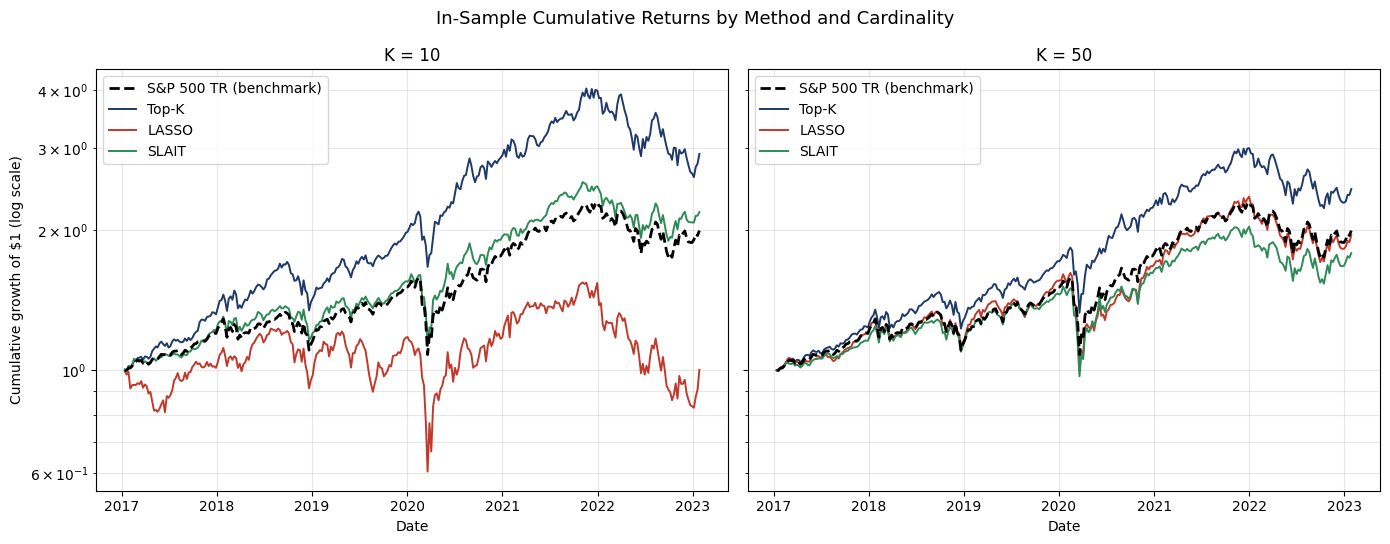

Final cumulative growth of $1 (in-sample):
  Benchmark:        1.993
  K=10:
    Top-K   : 2.913
    LASSO   : 1.000
    SLAIT   : 2.184
  K=50:
    Top-K   : 2.448
    LASSO   : 1.949
    SLAIT   : 1.783


In [37]:
# Visualization 1: cumulative returns, two panels (K=10 and K=50)
methods_to_plot = ['topk', 'lasso', 'slait']
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for panel_idx, K in enumerate([10, 50]):
    ax = axes[panel_idx]

    # Benchmark cumulative growth on the in-sample window
    bench_cum = (1 + index_returns_is).cumprod()
    ax.plot(bench_cum.index, bench_cum.values,
            color='#000000', linewidth=2.0, linestyle='--',
            label='S&P 500 TR (benchmark)', zorder=10)

    for method in methods_to_plot:
        key = (method, K)
        if key not in results_is or len(results_is[key]['costs']) == 0:
            continue
        port_returns = results_is[key]['returns']
        port_cum = (1 + port_returns).cumprod()
        ax.plot(port_cum.index, port_cum.values,
                color=method_colors[method], linewidth=1.4,
                label=method_labels[method])

    ax.set_yscale('log')
    ax.set_title(f'K = {K}')
    ax.set_xlabel('Date')
    if panel_idx == 0:
        ax.set_ylabel('Cumulative growth of $1 (log scale)')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper left')

fig.suptitle('In-Sample Cumulative Returns by Method and Cardinality', fontsize=13)
plt.tight_layout()
plt.show()

# Print final cumulative values for reference
print("Final cumulative growth of $1 (in-sample):")
bench_final = (1 + index_returns_is).prod()
print(f"  Benchmark:        {bench_final:.3f}")
for K in [10, 50]:
    print(f"  K={K}:")
    for method in methods_to_plot:
        key = (method, K)
        if key not in results_is or len(results_is[key]['costs']) == 0:
            print(f"    {method_labels[method]:8s}: —")
            continue
        final = (1 + results_is[key]['returns']).prod()
        print(f"    {method_labels[method]:8s}: {final:.3f}")

**Observations.** Two patterns stand out. First, at K=10 the methods diverge sharply. Top-K (blue) systematically overshoots the benchmark, ending the in-sample period roughly 40% above it; this reflects its concentration in the largest constituents (Apple, Microsoft, and similar), which outpaced the broad index over 2016-2023. SLAIT (green) tracks the benchmark closely throughout, confirming that a direct L0 solution can replicate the index with only ten assets. LASSO (red) fails badly: it collapses to 0.6 during the March 2020 COVID drawdown and ends the period essentially flat, consistent with its near-zero in-sample CAGR. With only about eight effective assets selected by L1 regularization, the LASSO portfolio is too concentrated and poorly diversified to track or grow.

Second, at K=50 the three methods converge tightly around the benchmark. LASSO recovers completely, now closely overlaying the index, which demonstrates that the method requires sufficient cardinality to function. Top-K still drifts above the benchmark, again because of its persistent overweight to mega-cap names.

A subtle but important point for interpretation: top-K's high cumulative return is not evidence of better tracking. It coincides with the highest tracking error among the methods (10.79% at K=10). The portfolio deviates from the index more than the others, and over this particular period the deviation happened to be favorable. Tracking quality is measured by closeness to the benchmark, not by outperformance — a portfolio that beats the index by a wide margin is, by definition, a poor tracker.

**Tracking Error by Cardinality**

The second visualization shows how annualized tracking error declines as the number of assets K increases. Tracking error is the primary metric for index replication: lower is better. Each method is plotted across its available cardinality grid — top-K and LASSO over K ∈ {10, 30, 50, 100}, and SLAIT over K ∈ {10, 50}. The benchmark itself has zero tracking error by construction and serves as the unreachable lower bound.

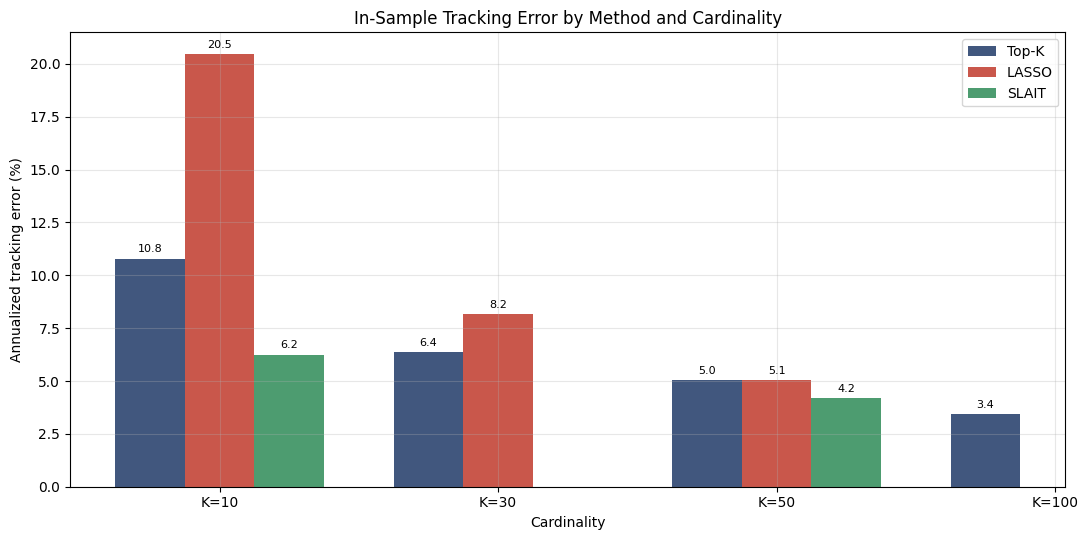

Annualized tracking error (%):
    K    Top-K    LASSO    SLAIT
   10    10.79    20.47     6.25
   30     6.35     8.16        —
   50     5.05     5.06     4.20
  100     3.44        —        —


In [39]:
# Visualization 2: tracking error vs K, grouped bar chart
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}

# Collect TE by method and K from the performance table
te_data = {}
for method in ['topk', 'lasso', 'slait']:
    te_data[method] = {}
    for _, row in performance_is.iterrows():
        if row['method'] == method and row['Status'] == 'ok':
            te_data[method][int(row['K'])] = row['TE_ann']

all_K = [10, 30, 50, 100]
x = np.arange(len(all_K))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, method in enumerate(['topk', 'lasso', 'slait']):
    heights = [te_data[method].get(K, np.nan) * 100 for K in all_K]
    offsets = x + (i - 1) * bar_width
    bars = ax.bar(offsets, heights, bar_width,
                  label=method_labels[method], color=method_colors[method], alpha=0.85)
    # Annotate each bar with its value
    for offset, h in zip(offsets, heights):
        if not np.isnan(h):
            ax.text(offset, h + 0.2, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'K={K}' for K in all_K])
ax.set_xlabel('Cardinality')
ax.set_ylabel('Annualized tracking error (%)')
ax.set_title('In-Sample Tracking Error by Method and Cardinality')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print the underlying values
print("Annualized tracking error (%):")
print(f"{'K':>5s} {'Top-K':>8s} {'LASSO':>8s} {'SLAIT':>8s}")
for K in all_K:
    topk_v = te_data['topk'].get(K)
    lasso_v = te_data['lasso'].get(K)
    slait_v = te_data['slait'].get(K)
    topk_s = f"{topk_v*100:.2f}" if topk_v is not None else "—"
    lasso_s = f"{lasso_v*100:.2f}" if lasso_v is not None else "—"
    slait_s = f"{slait_v*100:.2f}" if slait_v is not None else "—"
    print(f"{K:>5d} {topk_s:>8s} {lasso_s:>8s} {slait_s:>8s}")

**Observations.** Tracking error declines monotonically with cardinality for all three methods, as expected: more assets allow closer replication of the index. The differences between methods at low K are striking. SLAIT is the strongest tracker wherever it is evaluated. At K=10 it achieves a tracking error of 6.25%, which is lower than top-K at K=30 (6.35%) — in other words, SLAIT replicates the index with ten assets about as well as top-K does with thirty. At K=50 it again leads, at 4.20% versus 5.05% for top-K and 5.06% for LASSO.

LASSO is the weakest method at low cardinality (20.47% at K=10) but improves rapidly, matching top-K by K=50. This confirms the pattern seen in the cumulative-return plot: the L1-based selection only becomes viable once enough assets are admitted. Top-K declines smoothly across the full grid and reaches 3.44% at K=100.

The K=100 result for top-K should not be read as evidence that top-K is the best tracker at high cardinality. SLAIT was not evaluated at K=100 because of its compute cost, and given its dominance at K=10 and K=50, it would likely track at least as well there. The comparison is fair only where the methods share a cardinality level — namely K=10 and K=50 — and at both of those, SLAIT leads.

**Realised Cardinality of LASSO**

The earlier methodology fixed a deliberate design choice: for LASSO, the target K is the number of assets requested, but the post-refit step may zero out some of them, so the realised cardinality K_eff can fall below K. This visualization quantifies that gap. For each LASSO target K, it shows the distribution of K_eff across the 79 in-sample rebalances as a box plot, with the target level marked for reference. A consistent shortfall would indicate that LASSO settles on fewer assets than requested, while a tight match would indicate that the refit rarely discards selected assets.

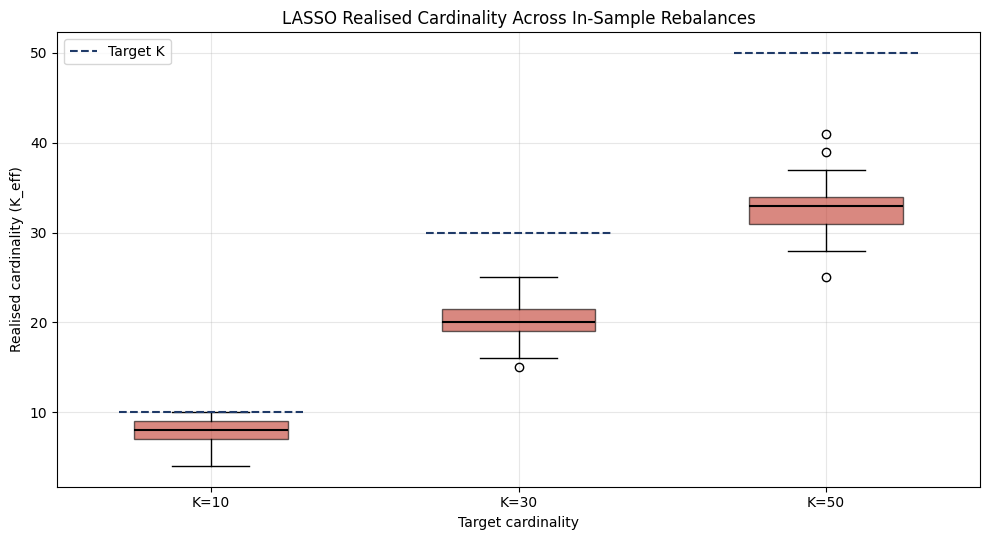

LASSO realised cardinality (K_eff) summary across 79 in-sample rebalances:
 Target K    mean  median   min   max  mean gap
       10    7.65     8.0     4    10      2.35
       30   20.23    20.0    15    25      9.77
       50   32.54    33.0    25    41     17.46


In [40]:
# Visualization 3: realised cardinality (K_eff) distribution for LASSO
lasso_color = '#c0392b'

lasso_K_targets = [K for (method, K) in results_is.keys()
                   if method == 'lasso' and len(results_is[('lasso', K)]['costs']) > 0]
lasso_K_targets = sorted(lasso_K_targets)

# Collect per-rebalance K_eff for each target K
k_eff_by_target = {}
for K in lasso_K_targets:
    weights_hist = results_is[('lasso', K)]['weights']
    k_eff_per_rebal = (weights_hist > 0).sum(axis=1)
    k_eff_by_target[K] = k_eff_per_rebal.values

fig, ax = plt.subplots(figsize=(10, 5.5))

positions = range(len(lasso_K_targets))
box_data = [k_eff_by_target[K] for K in lasso_K_targets]

bp = ax.boxplot(box_data, positions=list(positions), widths=0.5,
                patch_artist=True, medianprops={'color': 'black', 'linewidth': 1.5})
for patch in bp['boxes']:
    patch.set_facecolor(lasso_color)
    patch.set_alpha(0.6)

# Mark the target K level for each box with a dashed line segment
for i, K in enumerate(lasso_K_targets):
    ax.hlines(K, i - 0.3, i + 0.3, colors='#1f3a68', linestyles='--',
              linewidth=1.5, zorder=10,
              label='Target K' if i == 0 else None)

ax.set_xticks(list(positions))
ax.set_xticklabels([f'K={K}' for K in lasso_K_targets])
ax.set_xlabel('Target cardinality')
ax.set_ylabel('Realised cardinality (K_eff)')
ax.set_title('LASSO Realised Cardinality Across In-Sample Rebalances')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Print summary statistics
print("LASSO realised cardinality (K_eff) summary across 79 in-sample rebalances:")
print(f"{'Target K':>9s} {'mean':>7s} {'median':>7s} {'min':>5s} {'max':>5s} {'mean gap':>9s}")
for K in lasso_K_targets:
    arr = k_eff_by_target[K]
    gap = K - arr.mean()
    print(f"{K:>9d} {arr.mean():>7.2f} {np.median(arr):>7.1f} "
          f"{int(arr.min()):>5d} {int(arr.max()):>5d} {gap:>9.2f}")

**Observations.** LASSO consistently realises fewer assets than requested, and the shortfall grows with the target. At K=10 the median realised cardinality is 8 (a gap of about 2), at K=30 it is 20 (a gap of about 10), and at K=50 it is 33 (a gap of about 17). In relative terms, LASSO achieves roughly 65 to 77 percent of the requested cardinality, with the proportional shortfall increasing as K rises. The interquartile boxes lie entirely below the target line in all three cases, so this is a systematic property rather than occasional undershoot.

The mechanism is the post-refit step under non-negativity. When the L1 selection admits a set of assets and the budget-constrained refit reassigns weights with w ≥ 0, mutually redundant assets are pushed to the zero boundary and removed by the post-refit threshold. The larger the selected support, the more redundant pairs it contains, which is why the absolute shortfall widens with K. The spread also grows: the realised cardinality ranges over 6 assets at K=10 but over 16 assets at K=50, reflecting the data-dependent nature of which assets survive the refit at each rebalance.

This behavior is the reason the analysis reports both the target K and the mean K_eff. Comparisons against top-K and SLAIT, which hold exactly K assets, must account for the fact that LASSO is effectively operating at a lower cardinality than its label suggests — for instance, "LASSO at K=50" is in practice closer to a 33-asset portfolio.

**Portfolio Composition Stability**

The final visualization examines how stable each method's holdings are over time, which is the qualitative counterpart to the turnover metric. Three heatmaps, one per method at K=10, show the weight assigned to each asset (vertical axis) at each rebalance (horizontal axis). To keep the panels readable, each shows the twenty tickers most frequently held by that method, ordered by how often they appear. A method with stable composition produces solid horizontal bands — the same assets held with similar weights across time. A method with high turnover produces a fragmented, sparse pattern, with assets entering and leaving frequently.

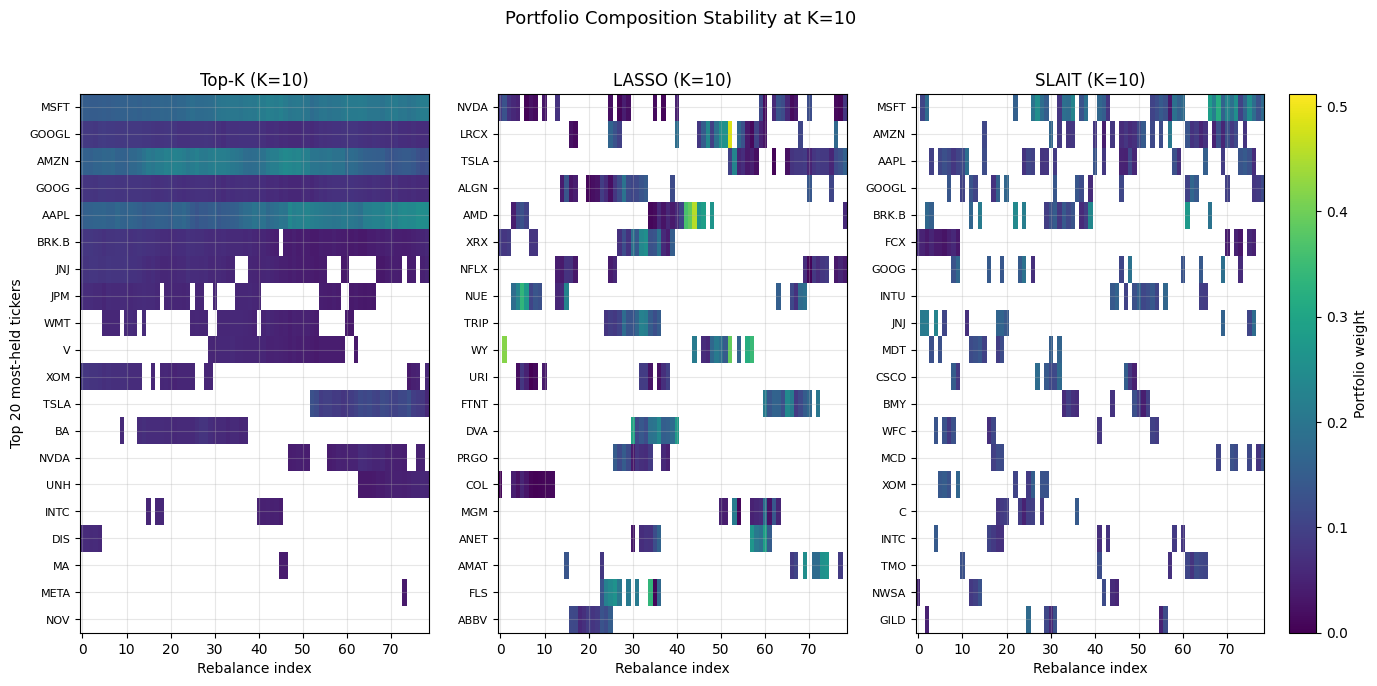

Composition stability summary (K=10):
method    unique tickers  mean holdings      top ticker (freq)
Top-K                 19          10.00           AAPL (79/79)
LASSO                113           7.65           NVDA (29/79)
SLAIT                257          10.01           MSFT (37/79)


In [42]:
# Visualization 4: composition stability heatmaps, three methods at K=10

methods_to_plot = ['topk', 'lasso', 'slait']
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharex=True)

for panel_idx, method in enumerate(methods_to_plot):
    ax = axes[panel_idx]
    weights_hist = results_is[(method, 10)]['weights'].copy()

    # Select the TOP_N tickers most frequently held (nonzero count across rebalances)
    appearance_count = (weights_hist > 0).sum(axis=0)
    top_tickers = appearance_count.sort_values(ascending=False).head(TOP_N).index
    # Order tickers by frequency (most frequent at top)
    sub = weights_hist[top_tickers].T  # rows = ticker, cols = rebalance date

    # Plot heatmap: weight as color, zeros shown as white
    data = sub.values
    masked = np.ma.masked_where(data == 0, data)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(masked, aspect='auto', cmap=cmap,
                   vmin=0, vmax=np.nanmax([np.nanmax(np.ma.masked_where(
                       results_is[(m, 10)]['weights'].values == 0,
                       results_is[(m, 10)]['weights'].values)) for m in methods_to_plot]))

    ax.set_yticks(range(len(top_tickers)))
    ax.set_yticklabels(top_tickers, fontsize=8)
    ax.set_title(f'{method_labels[method]} (K=10)')
    ax.set_xlabel('Rebalance index')
    if panel_idx == 0:
        ax.set_ylabel(f'Top {TOP_N} most-held tickers')

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='Portfolio weight')
fig.suptitle('Portfolio Composition Stability at K=10', fontsize=13, y=1.0)
plt.show()

# Print composition stability summary
print("Composition stability summary (K=10):")
print(f"{'method':<8s} {'unique tickers':>15s} {'mean holdings':>14s} {'top ticker (freq)':>22s}")
for method in methods_to_plot:
    weights_hist = results_is[(method, 10)]['weights']
    n_unique = (weights_hist > 0).any(axis=0).sum()
    mean_holdings = (weights_hist > 0).sum(axis=1).mean()
    appearance = (weights_hist > 0).sum(axis=0)
    top_ticker = appearance.idxmax()
    top_freq = appearance.max()
    print(f"{method_labels[method]:<8s} {n_unique:>15d} {mean_holdings:>14.2f} "
          f"{top_ticker + ' (' + str(int(top_freq)) + '/79)':>22s}")

**Observations.** The three methods differ dramatically in composition stability. Top-K is almost perfectly stable: its top holdings (MSFT, GOOGL, AMZN, GOOG, AAPL, BRK.B) form solid horizontal bands across all 79 rebalances, with AAPL held in every single one. Only 19 unique tickers pass through the portfolio over the full in-sample period, and the composition shifts only slowly as market capitalizations evolve. This is the visual signature of its low turnover (about 110% annualized).

LASSO is the opposite. Its holdings form a fragmented mosaic in which assets appear for a few rebalances and then vanish; 113 distinct tickers cycle through a portfolio that holds fewer than 8 at a time, and the most frequent holding (NVDA) appears in only 29 of 79 rebalances. Several assets receive very large weights for short stretches — AMD and a few others exceed 0.4 — which explains both the high volatility and the erratic returns of LASSO at K=10.

SLAIT presents a paradox worth highlighting. It cycles through the most unique tickers of all (257), yet it achieves the lowest tracking error (6.25%). A loose mega-cap core (MSFT, AMZN, AAPL) recurs more often than other names, but even the most frequent holding appears in fewer than half the rebalances. SLAIT attains close tracking precisely by continuously re-optimizing its composition against the most recent lookback window, rather than by holding a fixed set. High turnover is therefore not a defect of SLAIT but the mechanism behind its accuracy.

Taken together, the heatmaps reveal a stability-versus-accuracy trade-off at low cardinality. Top-K is stable and cheap to trade but tracks loosely; SLAIT tracks tightly but rebalances aggressively; LASSO combines instability with poor tracking, making it the weakest option at K=10. This is why turnover must be read alongside tracking error: a method that tracks well on paper may be expensive to run in practice, a tension examined directly in the transaction-cost sensitivity analysis of Notebook 03.

#Data Saving

The in-sample modeling is complete. All results required by the out-of-sample evaluation in Notebook 03_Evaluation are persisted to Google Drive as Parquet files. Because the three notebooks each redefine their shared functions (imports, configuration, fit functions, and the backtest engine), only data artifacts need to be saved here.

The artifacts fall into two groups: inputs that Notebook 03 will reuse directly (the share-count cache for the top-K market-cap proxy), and in-sample results retained for comparison against the out-of-sample period (backtest returns, costs, weights, and the performance table).

In [47]:
# Verify all expected artifacts exist and record a manifest

expected_artifacts = {
    'shares_outstanding.parquet':   'Share counts per ticker for top-K market-cap proxy (594 tickers)',
    'backtest_returns_is.parquet':  'In-sample weekly portfolio returns, net of TC, wide format (method_K columns)',
    'backtest_costs_is.parquet':    'In-sample per-rebalance transaction costs, wide format',
    'backtest_weights_is.parquet':  'In-sample rebalance weights, MultiIndex columns (method, K, ticker)',
    'performance_is.parquet':       'In-sample performance metrics table (10 method-K combinations)',
}

print("Verifying artifacts in CACHE_DIR:\n")
manifest = {
    'notebook': '02_modeling',
    'created': pd.Timestamp.now().isoformat(),
    'config': {
        'lookback_weeks': int(LOOKBACK_WEEKS),
        'rebalance_freq_weeks': int(REBALANCE_FREQ_WEEKS),
        'k_values_fast': list(K_VALUES_FAST),
        'k_values_slait': list(K_VALUES_SLAIT),
        'main_tc_bps': int(MAIN_TC_BPS),
        'n_is_rebalances': int(len(rebalance_dates_is)),
        'is_period_start': str(rebalance_dates_is[0].date()),
        'is_period_end': str(rebalance_dates_is[-1].date()),
    },
    'artifacts': {},
}

all_ok = True
for fname, description in expected_artifacts.items():
    fpath = os.path.join(CACHE_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        # Quick load test to confirm the file is readable
        try:
            df = pd.read_parquet(fpath)
            shape = df.shape
            status = 'OK'
        except Exception as e:
            shape = None
            status = f'READ ERROR: {e}'
            all_ok = False
        print(f"  {fname:<32s} {status:<6s} shape={shape}, {size_kb:.1f} KB")
        manifest['artifacts'][fname] = {
            'description': description,
            'shape': list(shape) if shape else None,
            'size_kb': round(size_kb, 1),
        }
    else:
        print(f"  {fname:<32s} MISSING")
        all_ok = False
        manifest['artifacts'][fname] = {'description': description, 'status': 'MISSING'}

# Save the manifest
manifest_path = os.path.join(CACHE_DIR, 'manifest_modeling.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"\nManifest saved: {manifest_path}")
print(f"Overall status: {'ALL ARTIFACTS OK' if all_ok else 'SOME ARTIFACTS MISSING OR UNREADABLE'}")

Verifying artifacts in CACHE_DIR:

  shares_outstanding.parquet       OK     shape=(594, 2), 14.1 KB
  backtest_returns_is.parquet      OK     shape=(316, 10), 35.0 KB
  backtest_costs_is.parquet        OK     shape=(79, 10), 13.8 KB
  backtest_weights_is.parquet      OK     shape=(79, 4739), 3319.8 KB
  performance_is.parquet           OK     shape=(10, 10), 6.7 KB

Manifest saved: /content/drive/MyDrive/ml_finance_project_index_tracking/cache_modeling/manifest_modeling.json
Overall status: ALL ARTIFACTS OK
